# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
os.getcwd()


'c:\\Users\\Cheng\\Documents\\GitHub\\datascience-publicpolicy-2026\\notebooks\\hw\\hw_3'

In [2]:
os.listdir("../../..")

['.git',
 '.gitignore',
 'data',
 'docs',
 'environment.yml',
 'notebooks',
 'pyproject.toml',
 'README.md',
 'references',
 'requirements.txt',
 'src',
 'uv.lock']

In [3]:
# 2. Acquire and load your primary dataset
def get_fred_data(series_id, api_key, start_date, end_date, freq='q'):
    url = f'https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={api_key}&observation_start={start_date}&observation_end={end_date}&file_type=json&frequency={freq}'
    response = requests.get(url)
    data = response.json()['observations']
    df = pd.json_normalize(data)
    return df

# Real Gross Domestic Product, billions of chained 2017 dollars, seasonally adjusted
gdp=get_fred_data('GDPC1', '2a8bad94ad24750f12c814fd1d2abb40', '1947-01-01', '2026-01-01', freq='q')

### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- **Dataset Source:** FRED API

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [4]:
# 1. Inspect data structure using pandas methods
gdp.head()

,realtime_start,realtime_end,date,value
0,2026-06-02,2026-06-02,1947-01-01,2182.681
1,2026-06-02,2026-06-02,1947-04-01,2176.892
2,2026-06-02,2026-06-02,1947-07-01,2172.432
3,2026-06-02,2026-06-02,1947-10-01,2206.452
4,2026-06-02,2026-06-02,1948-01-01,2239.682


In [5]:
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317 entries, 0 to 316
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   realtime_start  317 non-null    object
 1   realtime_end    317 non-null    object
 2   date            317 non-null    object
 3   value           317 non-null    object
dtypes: object(4)
memory usage: 10.0+ KB


In [6]:
# Convert Dtype of 'date' and 'value'
gdp['date'] = pd.to_datetime(gdp['date'])
gdp['value'] = pd.to_numeric(gdp['value'], errors='coerce')
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317 entries, 0 to 316
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   realtime_start  317 non-null    object        
 1   realtime_end    317 non-null    object        
 2   date            317 non-null    datetime64[ns]
 3   value           317 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 10.0+ KB


In [7]:
# 2. Rename columns and select a clean subset
gdp = gdp[['date', 'value']].rename(columns={'date':'quarter','value': 'gdp'})
gdp.head()


,quarter,gdp
0,1947-01-01,2182.681
1,1947-04-01,2176.892
2,1947-07-01,2172.432
3,1947-10-01,2206.452
4,1948-01-01,2239.682


In [8]:
# Get QoQ growth of GDP
gdp['gdp_growth'] = gdp['gdp'].pct_change() * 100

In [9]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE

In [10]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [11]:
# 1. Load and clean the secondary dataset
# Unemployment rate, seasonally adjusted
unemp=get_fred_data('UNRATE', '2a8bad94ad24750f12c814fd1d2abb40', '1948-01-01', '2026-04-01', freq='q')

# Convert Dtype of 'date' and 'value'
unemp['date'] = pd.to_datetime(unemp['date'])
unemp['value'] = pd.to_numeric(unemp['value'], errors='coerce')

# Rename columns and select a clean subset
unemp = unemp[['date', 'value']].rename(columns={'date':'quarter','value': 'unemp'})

# Get first difference of unemployment rate
unemp['d_unemp'] = unemp['unemp'].diff()
unemp.head()

,quarter,unemp,d_unemp
0,1948-01-01,3.7,NaN
1,1948-04-01,3.7,0.0
2,1948-07-01,3.8,0.1
3,1948-10-01,3.8,0.0
4,1949-01-01,4.7,0.9


In [12]:
# 2. Merge your datasets on a common key
df_merged = pd.merge(gdp, unemp, on='quarter', how='inner')
df_merged = df_merged[['quarter','gdp_growth', 'd_unemp']].dropna()
print(f"Total merged records: {len(df_merged)}")
df_merged.head()

Total merged records: 312


,quarter,gdp_growth,d_unemp
1,1948-04-01,1.652377,0.0
2,1948-07-01,0.574518,0.1
3,1948-10-01,0.113286,0.0
4,1949-01-01,-1.376614,0.9
5,1949-04-01,-0.339657,1.2


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- **Merge Key:** Quarter
- **Observations Retained:** 312

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [13]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# Bin GDP growth into economic regimes
bins = [-float('inf'), 0, 1, float('inf')]
labels = ['Recession', 'Slow Growth', 'Expansion']

df_merged['regime'] = pd.cut(df_merged['gdp_growth'], bins=bins, labels=labels)

# Groupby aggregation
regime_stats = df_merged.groupby('regime',observed=True)[['gdp_growth', 'd_unemp']].agg(['mean', 'median', 'min', 'max'])
print(regime_stats)

            gdp_growth                                 d_unemp              \
                  mean    median       min       max      mean median  min   
regime                                                                       
Recession    -0.921500 -0.525838 -7.876784 -0.022313  0.695349    0.4 -0.5   
Slow Growth   0.576774  0.612234  0.001993  0.988110  0.005556    0.0 -0.8   
Expansion     1.745994  1.645911  1.003753  7.762279 -0.282243   -0.2 -4.2   

                  
             max  
regime            
Recession    9.2  
Slow Growth  1.1  
Expansion    0.8  


- **Extra Credit:** 
    - The results across all three regimes are consistent with Okun's Law, whereby cyclical unemployment is typically associated with decline in real GDP. 
    - Under Recession regime, the economy contracted at an average rate of -0.92% per quarter, accompanied by a mean unemployment rate rise of +0.70 percentage points. Falling output pushes unemployment up. 
    - For the Expansion regime, the strong average GDP growth of 1.75% is accompanied by a mean unemployment rate decline of -0.28 percentage points. Robust output growth translates into labour market improvements. 
    - Under the Slow Growth regime, GDP grew modestly at 0.58% on average and unemployment was essentially flat (+0.006 percentage points on average). Growth must exceed a threshold to absorb labour. 

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

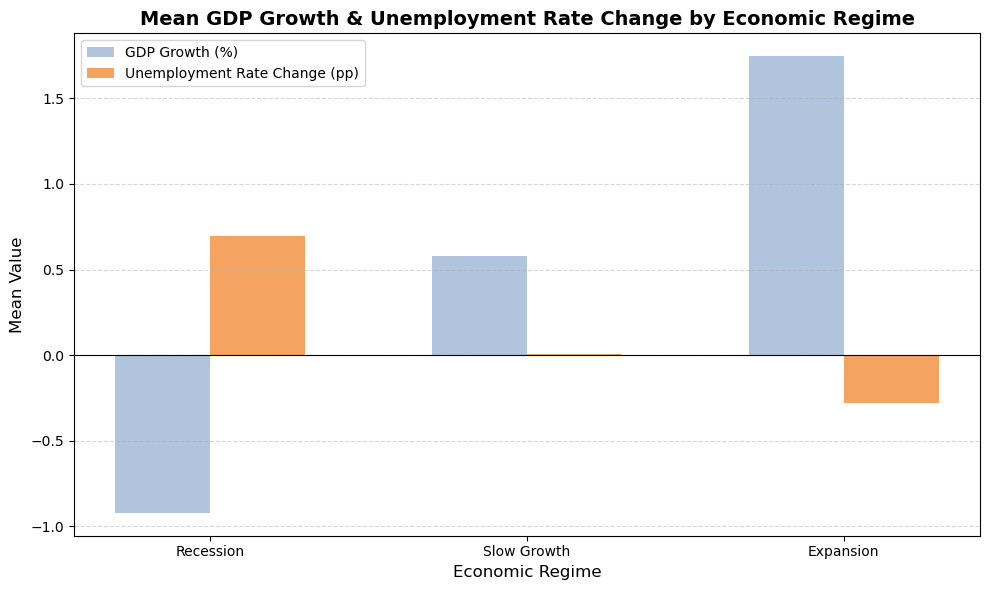

In [14]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
regime_mean = df_merged.groupby('regime', observed=True)[['gdp_growth', 'd_unemp']].mean()

x = np.arange(len(regime_mean.index))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, regime_mean['gdp_growth'], width, label='GDP Growth (%)', color='lightsteelblue')
bars2 = ax.bar(x + width/2, regime_mean['d_unemp'], width, label='Unemployment Rate Change (pp)', color='sandybrown')

ax.set_title("Mean GDP Growth & Unemployment Rate Change by Economic Regime", fontsize=14, fontweight='bold')
ax.set_xlabel("Economic Regime", fontsize=12)
ax.set_ylabel("Mean Value", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(regime_mean.index)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

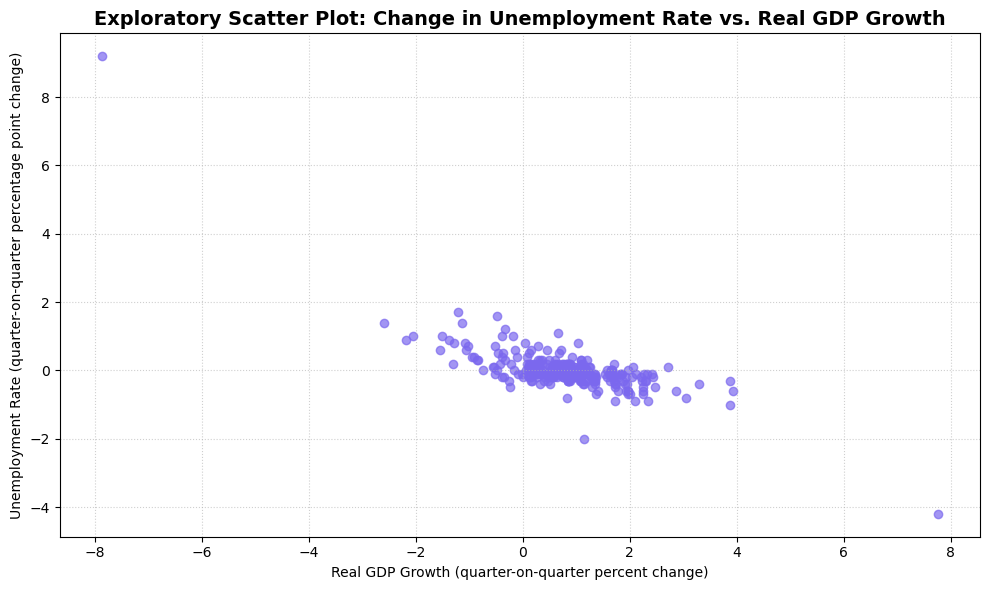

In [15]:
# Plot 2: Customized scatter plot of primary policy variables
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=df_merged['gdp_growth'], y=df_merged['d_unemp'], color='mediumslateblue', alpha=0.7)

ax.set_title("Exploratory Scatter Plot: Change in Unemployment Rate vs. Real GDP Growth", fontsize=14, fontweight='bold')
ax.set_xlabel("Real GDP Growth (quarter-on-quarter percent change)")
ax.set_ylabel("Unemployment Rate (quarter-on-quarter percentage point change)")
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

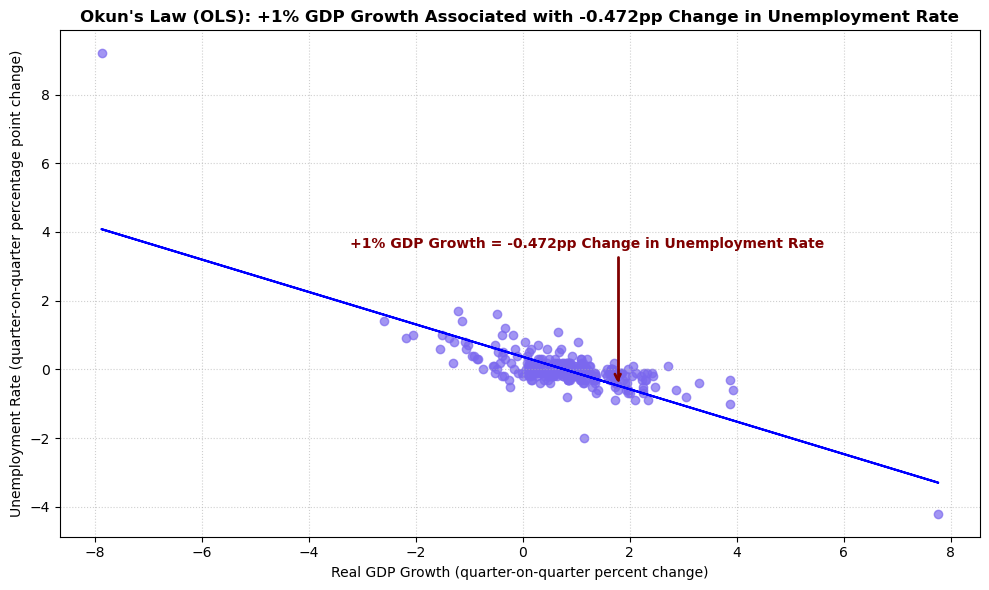

In [16]:
# Fit a simple linear regression and overlay the line of best fit
X = sm.add_constant(df_merged["gdp_growth"])
model = sm.OLS(df_merged["d_unemp"], X).fit()
b0, b1 = model.params.iloc[0], model.params.iloc[1]

x1 = df_merged["gdp_growth"].mean()
x2 = x1 + 1
y1 = b0 + b1 * x1
y2 = y1 + b1 * 1

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_merged["gdp_growth"], df_merged["d_unemp"], color="mediumslateblue", alpha=0.7)
ax.plot(df_merged["gdp_growth"], b0 + b1 * df_merged["gdp_growth"], color="blue")

ax.annotate(f"+1% GDP Growth = {b1:.3f}pp Change in Unemployment Rate", xy=(x2, y2), xytext=(x2 -5, y2 + 4), arrowprops=dict(arrowstyle="->", connectionstyle="angle,angleA=0,angleB=90", color="maroon", lw=2), weight="bold", color="maroon", fontsize=10)

ax.set_title(f"Okun's Law (OLS): +1% GDP Growth Associated with {b1:.3f}pp Change in Unemployment Rate", fontsize=12, weight="bold")
ax.set_xlabel("Real GDP Growth (quarter-on-quarter percent change)")
ax.set_ylabel("Unemployment Rate (quarter-on-quarter percentage point change)")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

- **Extra Credit**
    - **Scatter Plot:** There is a clear negative relationship between real GDP growth and changes in the unemployment rate, consistent with Okun's law. Most observations are clustered around the origin. This reflects that quarters of slow to moderate growth tend to see very marginal changes in unemployment. There are two notable outliers, one in the bottom-right corner and one in the top-left. The bottom-right corner represents very strong growth with a sharp unemployment drop. Meanwhile, the top-left corner represents a severe contraction with a large unemployment spike, which could correspond to major crises such as the GFC or COVID-19. 
    - **Regression:** The slope coefficient is -0.472, reflecting that a 1 percentage point increase in quarterly real GDP growth is associated with a 0.472 percentage point decrease in the unemployment rate, ceteris paribus. The negative sign aligns with what Okun's law predicts, i.e. faster output growth is associated with lower unemployment. The magnitude implies that the US labour market does not respond to output changes one-for-one.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.